In [40]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
# Read data
co2_NL_annual = pd.read_csv("annual-co2-emissions-per-country.csv")
co2_NL_annual = co2_NL_annual.drop(columns=["Code", "Entity"])

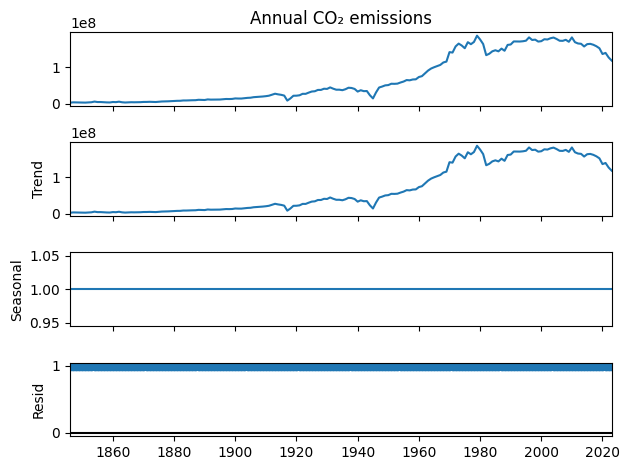

In [42]:
# Visualisations

# Detecting seasonality
# Set year as an index 
co2_NL_annual["Year"] = co2_NL_annual["Year"].astype(str)  # force string
co2_NL_annual.index = pd.to_datetime(co2_NL_annual["Year"], format="%Y")

# Decomposition
decomposed_co2_annual = seasonal_decompose(co2_NL_annual["Annual CO₂ emissions"], model='multiplicative', extrapolate_trend='freq')

decomposed_co2_annual.plot()
plt.tight_layout()
plt.show()

In [43]:
# Check if time series is stationary
adf_result = adfuller(co2_NL_annual["Annual CO₂ emissions"])

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

#Interpreting the results
if adf_result[1] < 0.05:
    print("The data is stationary (p-value < 0.05).")
else:
    print("The data is not stationary (p-value >= 0.05).")

ADF Statistic: -0.7530292835608328
p-value: 0.8325316650639782
The data is not stationary (p-value >= 0.05).


In [44]:
# Data differencing to remove trend 
data_diff = co2_NL_annual["Annual CO₂ emissions"].diff().dropna()
adf_result = adfuller(data_diff)

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])


ADF Statistic: -7.791541451990319
p-value: 7.917665798347198e-12


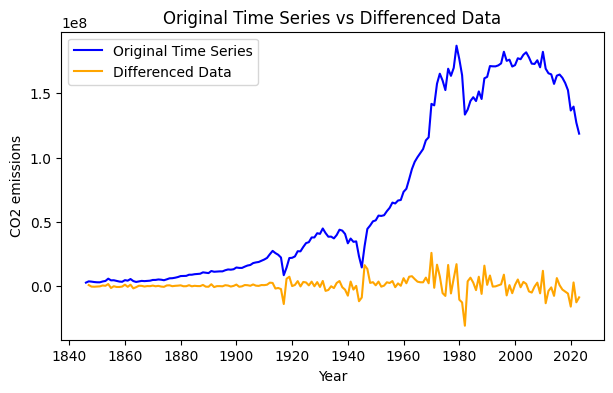

In [45]:
# Visualiasing the original and differenced data
plt.figure(figsize=(7, 4))

plt.plot(co2_NL_annual["Annual CO₂ emissions"], label='Original Time Series', color='blue')

plt.plot(data_diff, label='Differenced Data', color='orange')

plt.title('Original Time Series vs Differenced Data')
plt.xlabel('Year')
plt.ylabel('CO2 emissions')
plt.legend()
plt.show()

In [46]:
# Split data
split_idx = int(len(data_diff) * 0.8)
train = data_diff.iloc[:split_idx]
test = data_diff.iloc[split_idx:]

# Test for p and q between 0 and 3
p_val = range(0,4)
q_val = range(0,4)

# Set values to track
best_aic = float("inf")
best_order = None
best_model = None

# Fit ARIMA model 
for p in p_val:
    for q in q_val:
        try:
            model = ARIMA(train, order=(p, 0, q))
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, 0, q)
                best_model = model_fit
        except:
            continue

print(f"The best ARIMA model order: {best_order} with AIC: {best_aic}")


c:\Users\mkubara.NMKESBACO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\mkubara.NMKESBACO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\mkubara.NMKESBACO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\mkubara.NMKESBACO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates

The best ARIMA model order: (1, 0, 0) with AIC: 4787.65198567975


c:\Users\mkubara.NMKESBACO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


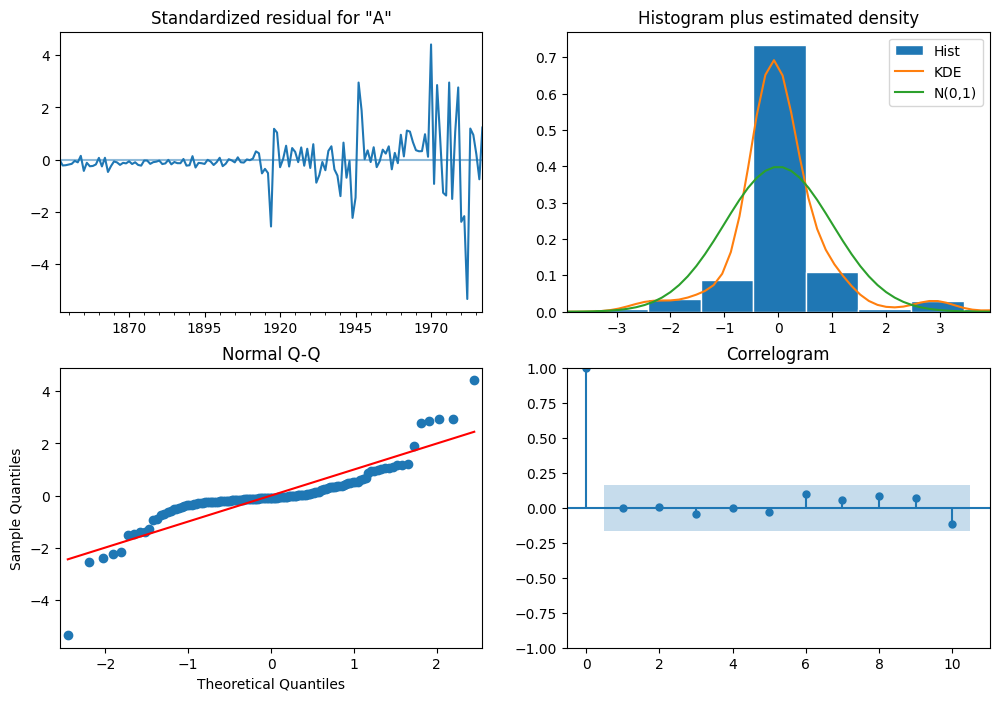

In [47]:
best_model.plot_diagnostics(figsize=(12,8))
plt.show()

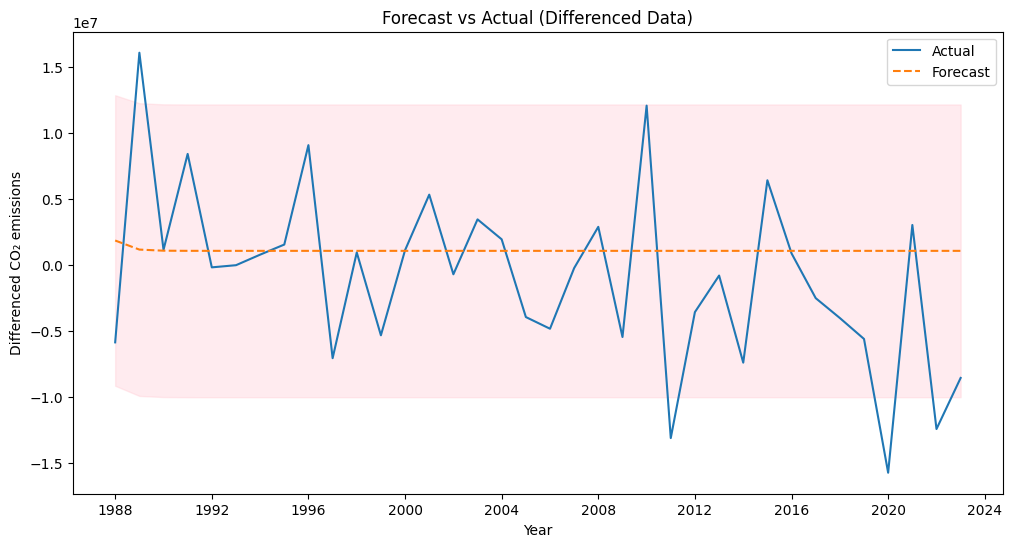

Mean Absolute Error (MAE): 5239765.922974388
Root Mean Squared Error (RMSE): 6946589.53613601


In [ ]:
# Predictions
# Number of data points to froecast
steps = len(test)

# Forecast the differenced data for the test period
forecast = best_model.get_forecast(steps=steps)
predicted = forecast.predicted_mean

# Confidence intervals
conf_int = forecast.conf_int()

#PLot true vs forcasted values
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predicted, label='Forecast', linestyle='--')
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='pink', alpha=0.3)
plt.title('Forecast vs Actual (Differenced Data)')
plt.xlabel('Year')
plt.ylabel('Differenced CO₂ emissions')
plt.legend()
plt.show()

mae = mean_absolute_error(test, predicted)
rmse = np.sqrt(mean_squared_error(test, predicted))

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse}')


The model predicts little to no change in CO2 emissions differences for the forecast period. The original data displays high volatility and large fluctuations, however, the forecast is very smooth, not taking into account these fluctuations. Differencing of the data helped achieveing stationarity, however, potentially some meaningful information was lost. Maybe other models such ARCH for volatility should be used. Overall, the current ARIMA model serves as a good baseline model and provides meaningful information regarding the general trend and short-term dynamics of CO₂ emissions, but further model refinement is needed to fully capture the underlying variability and improve forecast accuracy.